# Multi-Dimensional C Node: Nonstationarity Basis Functions

CDNOTS uses a **C node** (nonstationarity indicator) to detect and orient
edges whose mechanism changes over time. By default, C is a scalar linear time
index `t`. This notebook shows:

1. **Why C matters** — omitting C on nonstationary data creates spurious edges
   between unrelated variables that share a common time trend.
2. **How to choose the right C basis** — the C shape must match the
   nonstationarity pattern; a linear C cannot absorb a quadratic trend.

| Preset | C columns | Best for |
|--------|-----------|----------|
| `'linear'` | `[t]` | Smooth monotone drift (default) |
| `'step'` | `[1_{t≥T/2}]` | Sudden regime change at midpoint |
| `'step+linear'` | `[1_{t≥T/2}, t]` | Regime change + gradual drift |
| `'linear+sin'` | `[t, sin(2πt/T)]` | Drift + periodic seasonal effect |
| `'linear+exp'` | `[t, eˢᵗ/ᵀ−1]` | Drift + accelerating change |
| `'linear+quad'` | `[t, t²/T]` | Quadratic drift |

Or supply any `(T, k)` array via `c_array=...` for full control.

Sections 7–8 add **CEDAR** results alongside CDNOTS for both datasets, with a side-by-side comparison bar chart.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts import run_cdnots, make_c_array
from causalts.cedar import run_cedar
from causalts.ci_tests import ParCorrGPU
from causalts.utils import evaluate_graph
from causalts.synthetic_data.synthetic_datasets import confounded_trends, ex1_nonstationary

## 1. Why C matters — Spurious confounding from shared trends

Imagine chocolate sales, sunburn cases, and fuel consumption all growing over time
(population growth). Without conditioning on time, a causal discovery algorithm
will find spurious links between them: "ice cream causes sunburn", etc.

We build a 7-variable system where **all five trend-driven variables are roots** —
none of them cause each other. The shared driver is population growth.

| Variable | Trend | True parents |
|----------|-------|--------------|
| Chocolate | quadratic | — (root) |
| IceCream | quadratic | — (root) |
| Sunburn | quadratic + self-lag | — (root, population drives sunburn cases) |
| Airline | quadratic | — (root) |
| Fuel | quadratic + self-lag | — (root, population drives fuel consumption) |
| Temp | self-lag | — (root, no trend) |
| Energy | none | Temp(t-2) — the only genuine causal link |

Without C, the algorithm links the trend-driven variables spuriously.
With  C, all spurious edges vanish and only Temp→Energy remains.


Dataset : Confounded Trends (7-Node)
Shape   : T=500, d=7, true edges=5


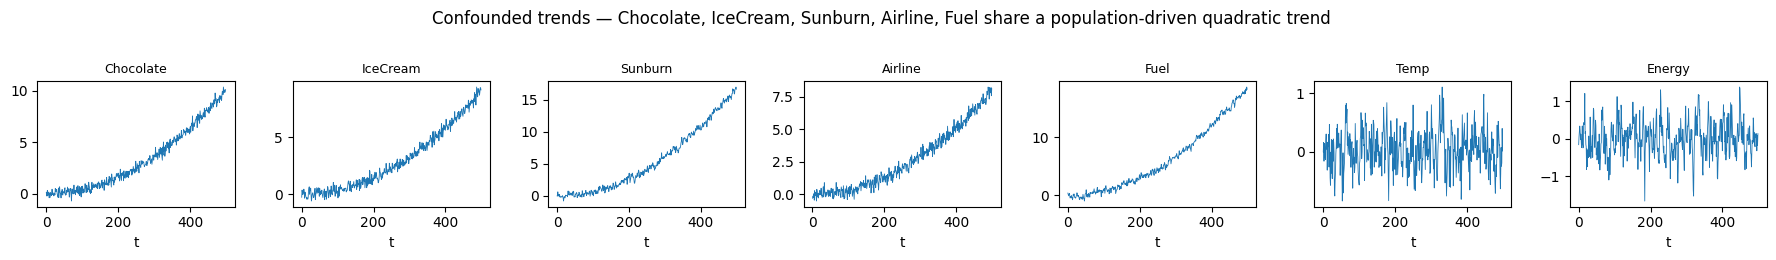

In [3]:
ds = confounded_trends(seed=42, T=500)
df = ds['df']
gt = ds['ground_truth']
max_lag = ds['max_lag']
var_names = ds['var_names']
T = len(df)
d = df.shape[1]
print(f"Dataset : {ds['name']}")
print(f"Shape   : T={T}, d={d}, true edges={int(gt.sum())}")

fig, axes = plt.subplots(1, d, figsize=(18, 2.5), sharey=False)
for ax, col in zip(axes, df.columns):
    ax.plot(df[col].values, lw=0.6)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('t')
plt.suptitle('Confounded trends — Chocolate, IceCream, Sunburn, Airline, Fuel share a population-driven quadratic trend',
             y=1.02)
plt.tight_layout()
plt.show()

## 2. Discovery with and without C

The omitted confounder here is **population growth** — it drives chocolate sales,
ice cream sales, and airline revenue upward, but none of them cause each other.
A quadratic C node (`linear+quad`) acts as a proxy for this unobserved population
factor, absorbing the shared trend so the algorithm doesn't hallucinate edges.

In [5]:
presets = ['linear', 'step', 'step+linear', 'linear+sin', 'linear+exp', 'linear+quad']
results = {}   # (metrics, graph[:d,:d,:]) keyed by preset
result_objs = {}  # full CdnotsResult keyed by preset

# Baseline: no C
cit = ParCorrGPU(np.zeros((2, 2)))
res_nc = run_cdnots(df, cit, num_lags=max_lag, include_C=False, alpha=0.05, show_progress=False)
g_nc = res_nc.cg_tig
m_nc = evaluate_graph(g_nc, gt)
results['no C'] = (m_nc, g_nc)
spur = int(g_nc.sum()) - m_nc['TP']
print(f"{'no C':<18} F1={m_nc['F1']:.3f}  Prec={m_nc['Precision']:.3f}  Rec={m_nc['TPR']:.3f}  SHD={m_nc['SHD']}  spurious={spur}")

# Each preset
for preset in presets:
    cit = ParCorrGPU(np.zeros((2, 2)))
    res = run_cdnots(df, cit, num_lags=max_lag, include_C=True,
                     c_preset=preset, alpha=0.05, show_progress=False)
    result_objs[preset] = res
    g = res.cg_tig[:d, :d, :]
    m = evaluate_graph(g, gt)
    results[preset] = (m, g)
    spur = int(g.sum()) - m['TP']
    print(f"{preset:<18} F1={m['F1']:.3f}  Prec={m['Precision']:.3f}  Rec={m['TPR']:.3f}  SHD={m['SHD']}  spurious={spur}  (k={res.num_c_cols})")


no C               F1=0.294  Prec=0.172  Rec=1.000  SHD=24  spurious=24
linear             F1=0.333  Prec=0.200  Rec=1.000  SHD=20  spurious=20  (k=1)
step               F1=0.294  Prec=0.172  Rec=1.000  SHD=24  spurious=24  (k=1)
step+linear        F1=0.333  Prec=0.200  Rec=1.000  SHD=20  spurious=20  (k=2)
linear+sin         F1=0.333  Prec=0.200  Rec=1.000  SHD=20  spurious=20  (k=2)
linear+exp         F1=0.400  Prec=0.250  Rec=1.000  SHD=15  spurious=15  (k=2)
linear+quad        F1=0.769  Prec=0.625  Rec=1.000  SHD=3  spurious=3  (k=2)


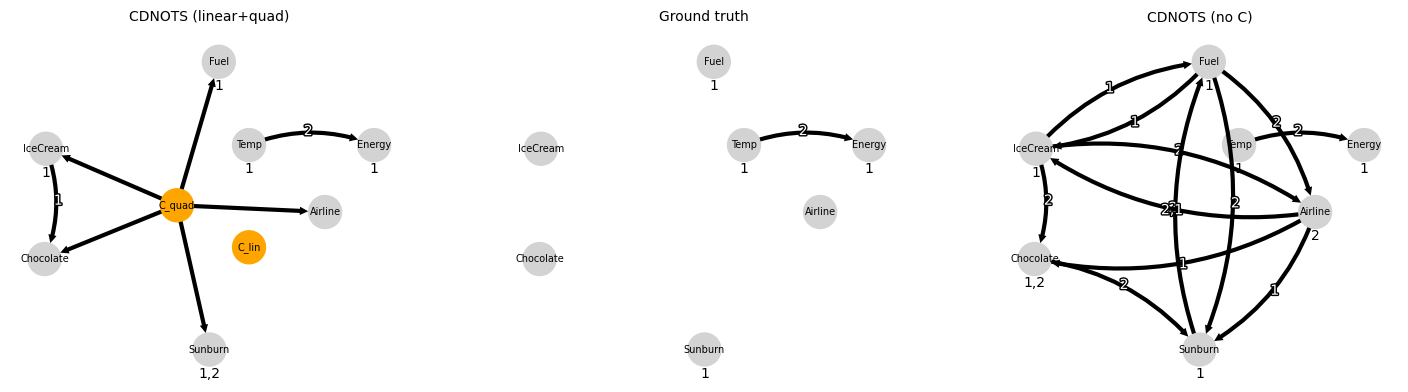

In [4]:
import causalts.plotting as tp

res_lq = result_objs['linear+quad']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

c_highlight = {('C_lin', 0): 'orange', ('C_quad', 0): 'orange'}
pos = res_lq.plot(
    arrow_linewidth=3,
    node_layout='sfdp',
    fig_ax=(fig, axes[0]),
    node_label_size=7,
    node_size=0.2,
    special_nodes=c_highlight,
    show_autodependency_lags=True,
    return_pos=True,
)

tp.plot_graph(
    gt,
    var_names=var_names,
    node_pos=pos[2],
    node_label_size=7,
    node_size=0.2,
    arrow_linewidth=3,
    show_autodependency_lags=True,
    fig_ax=(fig, axes[1]),
)

res_nc.plot(
    arrow_linewidth=3,
    node_pos=pos[2],
    node_label_size=7,
    node_size=0.2,
    special_nodes=c_highlight,
    show_autodependency_lags=True,
    fig_ax=(fig, axes[2]),
)

axes[0].set_title('CDNOTS (linear+quad)', fontsize=10)
axes[1].set_title('Ground truth', fontsize=10)
axes[2].set_title('CDNOTS (no C)', fontsize=10)
plt.tight_layout()
plt.show()


## 3. Spurious edges without C

Without C, the shared population trend makes the algorithm hallucinate causal
links between Chocolate, IceCream, Sunburn, Airline, and Fuel. With `linear+quad`
(which matches the quadratic trend), most spurious edges vanish.


In [5]:
print("=== Spurious edges WITHOUT C ===")
m_nc, g_nc = results['no C']
for i in range(d):
    for j in range(d):
        for lag in range(g_nc.shape[2]):
            if g_nc[i, j, lag] and gt[i, j, lag] != 1:
                print(f"  {var_names[i]}(t-{lag}) -> {var_names[j]}")

print(f"\n=== Spurious edges WITH C (linear+quad) ===")
m_p2, g_p2 = results['linear+quad']
found = False
for i in range(d):
    for j in range(d):
        for lag in range(g_p2.shape[2]):
            if g_p2[i, j, lag] and gt[i, j, lag] != 1:
                print(f"  {var_names[i]}(t-{lag}) -> {var_names[j]}")
                found = True
if not found:
    print("  (none)")

=== Spurious edges WITHOUT C ===
  Chocolate(t-1) -> Chocolate
  Chocolate(t-2) -> Chocolate
  Chocolate(t-2) -> Sunburn
  IceCream(t-2) -> Chocolate
  IceCream(t-1) -> IceCream
  IceCream(t-2) -> Airline
  IceCream(t-1) -> Fuel
  Sunburn(t-2) -> Fuel
  Airline(t-1) -> Chocolate
  Airline(t-1) -> IceCream
  Airline(t-2) -> IceCream
  Airline(t-1) -> Sunburn
  Airline(t-2) -> Airline
  Fuel(t-1) -> IceCream
  Fuel(t-2) -> Sunburn
  Fuel(t-2) -> Airline

=== Spurious edges WITH C (linear+quad) ===
  IceCream(t-1) -> Chocolate
  IceCream(t-1) -> IceCream
  Sunburn(t-2) -> Sunburn


## 4. Bar chart comparison

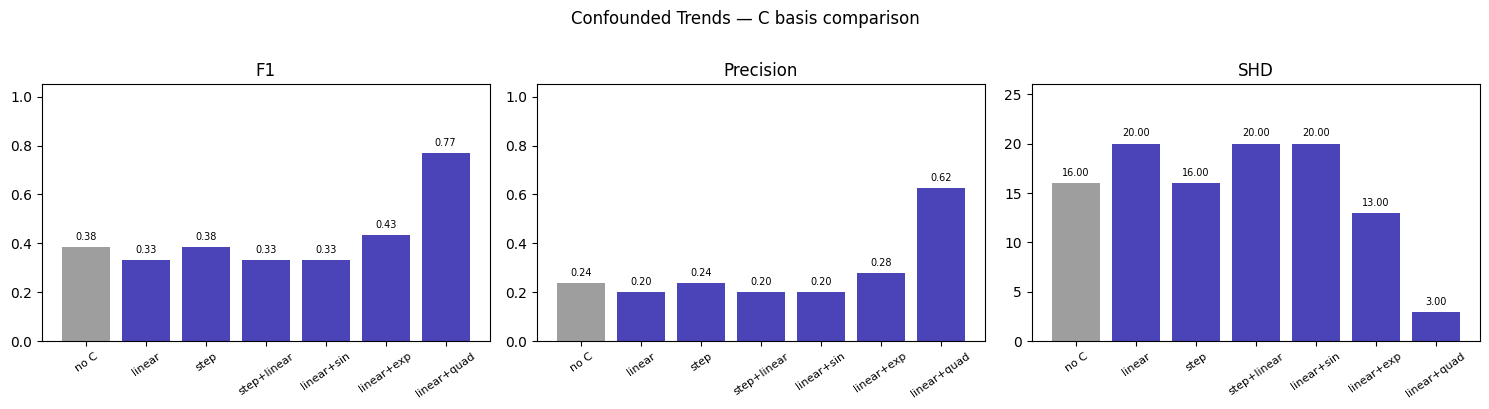

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = list(results.keys())
f1s    = [results[k][0]['F1'] for k in labels]
precs  = [results[k][0]['Precision'] for k in labels]
shds   = [results[k][0]['SHD'] for k in labels]
colors = ['#9E9E9E'] + ['#4B44B8'] * len(presets)

for ax, vals, title, ymax in zip(
    axes,
    [f1s, precs, shds],
    ['F1', 'Precision', 'SHD'],
    [1.05, 1.05, max(shds) * 1.3],
):
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax*0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Confounded Trends — C basis comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Show which variables the algorithm found to have C edges
res_lsin = result_objs['linear+sin']
tig = res_lsin.cg_tig  # shape (d + num_c_cols, d + num_c_cols, num_lags+1)
n_total = tig.shape[0]
c_start = n_total - res_lsin.num_c_cols

print("Edges from C columns to X variables (C -> X) for linear+sin:")
for c_i in range(c_start, n_total):
    c_label = res_lsin.c_node_names[c_i - c_start]
    for j in range(d):
        if tig[c_i, j, 0] == 1:
            print(f"  {c_label} -> {var_names[j]}")

print()
print("True nonstationary variables (population-trend driven):")
print("  Chocolate, IceCream, Sunburn, Airline, Fuel")


Edges from C columns to X variables (C -> X) for linear+sin:
  C_lin -> Fuel

True nonstationary variables (population-trend driven):
  Chocolate, IceCream, Sunburn, Airline, Fuel


---
## 7. CEDAR on Confounded Trends

Running the same C-preset sweep with CEDAR alongside CDNOTS.

> **Why `lag_method='dcor'` is forced here:** CEDAR's default lag method is
> `partial_dcor`, which residualises each target Y on Y(t-1) before scoring lags.
> This removes the shared quadratic trend from Y at the lag-selection phase —
> so CEDAR already achieves F1=1.0 on cross-variable edges *without* C when using
> `partial_dcor` (the default). To demonstrate the value of the C node, this section
> forces `lag_method='dcor'` (raw distance correlation, no residualisation). With
> plain dcor the trend contaminates the lag-importance scores, and C becomes necessary
> to separate true causal edges from trend-driven spurious associations.

> **Evaluation:** self-loops excluded (`exclude_self_loops=True`) — both algorithms
> are judged on the same cross-variable target set.

In [6]:
cedar_results = {}   # (metrics, graph[:d,:d,:]) keyed by preset

# Baseline: no C
cit = ParCorrGPU(np.zeros((2, 2)))
# lag_method='dcor': forced here to demonstrate C-node benefit.
# With the default 'partial_dcor', CEDAR residualises Y on Y(t-1) before
# scoring lags, removing the trend signal — F1=1.0 even without C.
cedar_nc = run_cedar(df, cit, max_lag=max_lag, include_C=False, lag_method='dcor')
g_nc_s = cedar_nc.cg_tig[:d, :d, :]
gt_cross = gt.copy()
for _lag in range(gt_cross.shape[2]):
    np.fill_diagonal(gt_cross[:, :, _lag], 0)
m_nc_s = evaluate_graph(g_nc_s, gt_cross, exclude_self_loops=True) # CEDAR assumes autoregressive edges by design but does not test for them. Therefore, we exclude self-loops from evaluation.
cedar_results['no C'] = (m_nc_s, g_nc_s)
spur_s = int(g_nc_s.sum()) - m_nc_s['TP']
print(f"{'no C':<18} F1={m_nc_s['F1']:.3f}  Prec={m_nc_s['Precision']:.3f}  "
      f"Rec={m_nc_s['TPR']:.3f}  SHD={m_nc_s['SHD']}  spurious={spur_s}")

for preset in presets:
    cit = ParCorrGPU(np.zeros((2, 2)))
    res_s = run_cedar(df, cit, max_lag=max_lag, include_C=True, c_preset=preset, lag_method='dcor')
    n_c_s = len(res_s.c_node_names)
    g_s = res_s.cg_tig[:d, :d, :]
    m_s = evaluate_graph(g_s, gt_cross, exclude_self_loops=True)
    cedar_results[preset] = (m_s, g_s)
    spur_s = int(g_s.sum()) - m_s['TP']
    print(f"{preset:<18} F1={m_s['F1']:.3f}  Prec={m_s['Precision']:.3f}  "
          f"Rec={m_s['TPR']:.3f}  SHD={m_s['SHD']}  spurious={spur_s}  (k={n_c_s})")

no C               F1=0.200  Prec=0.111  Rec=1.000  SHD=8  spurious=15
linear             F1=0.333  Prec=0.200  Rec=1.000  SHD=4  spurious=11  (k=1)
step               F1=0.333  Prec=0.200  Rec=1.000  SHD=4  spurious=11  (k=1)
step+linear        F1=0.333  Prec=0.200  Rec=1.000  SHD=4  spurious=11  (k=2)
linear+sin         F1=0.333  Prec=0.200  Rec=1.000  SHD=4  spurious=11  (k=2)
linear+exp         F1=0.500  Prec=0.333  Rec=1.000  SHD=2  spurious=9  (k=2)
linear+quad        F1=1.000  Prec=1.000  Rec=1.000  SHD=0  spurious=7  (k=2)


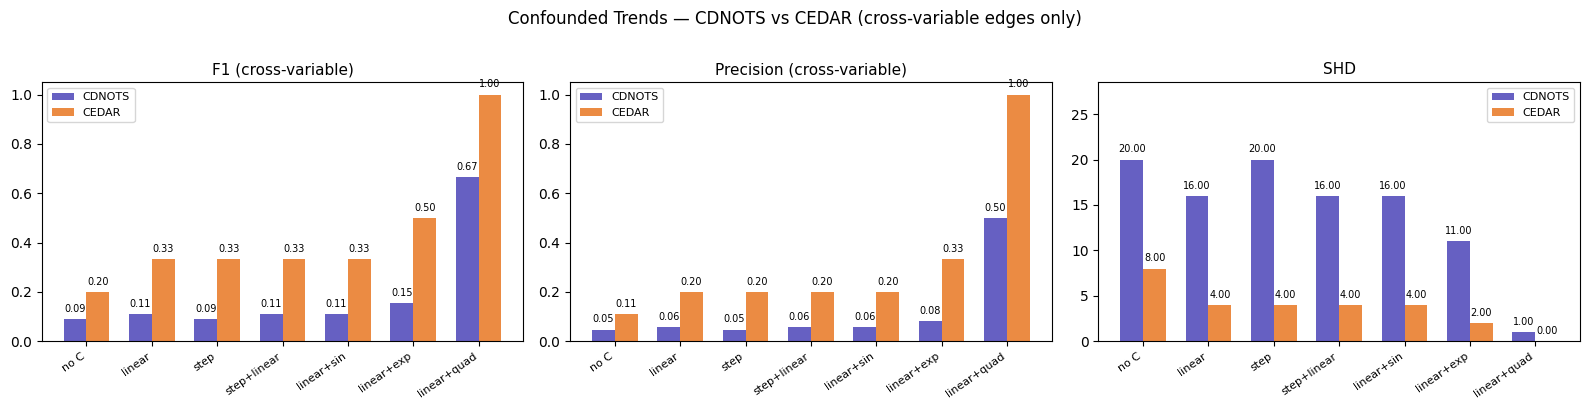

In [7]:
# Side-by-side bar chart: CDNOTS vs CEDAR on confounded_trends
# For fair comparison, evaluate CDNOTS cross-variable edges too
cdnots_cross = {}
for key, (m, g) in results.items():
    m_c = evaluate_graph(g[:d, :d, :] if g.shape[0] > d else g, gt_cross, exclude_self_loops=True)
    cdnots_cross[key] = m_c

labels_ct = list(cedar_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(labels_ct))
w = 0.35

for ax, metric, title, ymax in zip(
    axes,
    ['F1', 'Precision', 'SHD'],
    ['F1 (cross-variable)', 'Precision (cross-variable)', 'SHD'],
    [1.05, 1.05, None],
):
    cdnots_vals = [cdnots_cross[k][metric] for k in labels_ct]
    cedar_vals   = [cedar_results[k][0][metric] for k in labels_ct]
    if ymax is None:
        ymax = max(max(cdnots_vals), max(cedar_vals)) * 1.4 + 0.5

    b1 = ax.bar(x - w/2, cdnots_vals, w, label='CDNOTS', color='#4B44B8', alpha=0.85)
    b2 = ax.bar(x + w/2, cedar_vals,   w, label='CEDAR',  color='#E87722', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_ct, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    for bar, v in zip(list(b1) + list(b2), cdnots_vals + cedar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax*0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Confounded Trends — CDNOTS vs CEDAR (cross-variable edges only)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## 5. Mechanism nonstationarity — variable-strength causal effects

The previous example used C to absorb an **unobserved confounder** (population
growth). Here we look at what CDNOTS was primarily designed for: causal
**mechanisms that change over time**.

The `ex1_nonstationary` system has 5 variables with the following structure:

| Variable | Mechanism | Nonstationarity |
|----------|-----------|------------------|
| X0 | X0(t-1), X1(t-2) | quadratic drift in additive noise (t²) |
| X1 | X1(t-1) | quadratic drift (t²) |
| X2 | X2(t-1) | sinusoidal drift sin(t/20) |
| X3 | X3(t-1), X2(t-2) | stationary |
| X4 | X4(t-1), X3(t-1) | stationary |

X0 and X1 need a **quadratic C** to condition out their drift; X2 needs a
**sinusoidal C**. A custom `c_array` combining both handles the full system.


Dataset : 5-Node Nonstationary System
Shape   : T=300, d=5, true edges (X only)=8


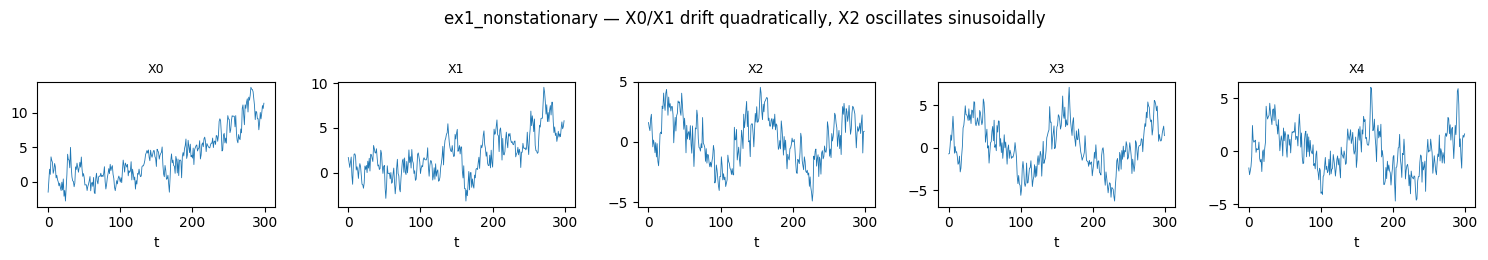

In [9]:
ds2 = ex1_nonstationary(seed=32, T=300,trend_strength=1)
df2 = ds2['df']
gt2 = ds2['ground_truth']   # shape (6, 6, 3) — 5 vars + single C at index 5
max_lag2 = ds2['max_lag']
var_names2 = ds2['var_names']
d2 = df2.shape[1]
T2 = len(df2)
print(f"Dataset : {ds2['name']}")
print(f"Shape   : T={T2}, d={d2}, true edges (X only)={int(gt2[:d2,:d2,:].sum())}")

fig, axes = plt.subplots(1, d2, figsize=(15, 2.5), sharey=False)
for ax, col in zip(axes, df2.columns):
    ax.plot(df2[col].values, lw=0.6)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('t')
plt.suptitle('ex1_nonstationary — X0/X1 drift quadratically, X2 oscillates sinusoidally',
             y=1.02)
plt.tight_layout()
plt.show()


## 6. C basis comparison on mechanism nonstationarity

We evaluate each preset against only the X-to-X edges (first 5 variables),
since the number of C columns varies by preset. We then separately check which
C→X edges were recovered.


In [10]:
gt2_x = gt2[:d2, :d2, :]  # X-only ground truth for fair comparison across presets

presets2 = ['linear', 'linear+quad', 'linear+sin']
results2 = {}
result_objs2 = {}

# Baseline: no C
cit = ParCorrGPU(np.zeros((2, 2)))
res2_nc = run_cdnots(df2, cit, num_lags=max_lag2, include_C=False, alpha=0.05, show_progress=False)
g_nc2 = res2_nc.cg_tig[:d2, :d2, :]
m_nc2 = evaluate_graph(g_nc2, gt2_x)
results2['no C'] = (m_nc2, g_nc2)
spur = int(g_nc2.sum()) - m_nc2['TP']
print(f"{'no C':<18} F1={m_nc2['F1']:.3f}  Prec={m_nc2['Precision']:.3f}  Rec={m_nc2['TPR']:.3f}  SHD={m_nc2['SHD']}  spurious={spur}")

for preset in presets2:
    cit = ParCorrGPU(np.zeros((2, 2)))
    res2 = run_cdnots(df2, cit, num_lags=max_lag2, include_C=True,
                      c_preset=preset, alpha=0.05, show_progress=False)
    result_objs2[preset] = res2
    g2 = res2.cg_tig[:d2, :d2, :]
    m2 = evaluate_graph(g2, gt2_x)
    results2[preset] = (m2, g2)
    spur = int(g2.sum()) - m2['TP']
    print(f"{preset:<18} F1={m2['F1']:.3f}  Prec={m2['Precision']:.3f}  Rec={m2['TPR']:.3f}  SHD={m2['SHD']}  spurious={spur}  (k={res2.num_c_cols})")

# Custom c_array: combine quad + sin to handle both drift types
t = np.arange(T2, dtype=float)
c_custom = np.column_stack([t, t ** 2 / T2, np.sin(t / 20)])
cit = ParCorrGPU(np.zeros((2, 2)))
res2_cust = run_cdnots(df2, cit, num_lags=max_lag2, include_C=True,
                       c_array=c_custom, alpha=0.05, show_progress=False)
result_objs2['custom (quad+sin)'] = res2_cust
g2_cust = res2_cust.cg_tig[:d2, :d2, :]
m2_cust = evaluate_graph(g2_cust, gt2_x)
results2['custom (quad+sin)'] = (m2_cust, g2_cust)
spur = int(g2_cust.sum()) - m2_cust['TP']
print(f"{'custom (quad+sin)':<18} F1={m2_cust['F1']:.3f}  Prec={m2_cust['Precision']:.3f}  Rec={m2_cust['TPR']:.3f}  SHD={m2_cust['SHD']}  spurious={spur}  (k={res2_cust.num_c_cols})")


no C               F1=0.800  Prec=0.667  Rec=1.000  SHD=4  spurious=4
linear             F1=0.941  Prec=0.889  Rec=1.000  SHD=1  spurious=1  (k=1)
linear+quad        F1=0.941  Prec=0.889  Rec=1.000  SHD=1  spurious=1  (k=2)
linear+sin         F1=0.941  Prec=0.889  Rec=1.000  SHD=1  spurious=1  (k=2)
custom (quad+sin)  F1=1.000  Prec=1.000  Rec=1.000  SHD=0  spurious=0  (k=3)


In [11]:
# Which C→X edges did the best model (custom) recover?
tig_cust = res2_cust.cg_tig
n_total = tig_cust.shape[0]
c_start = n_total - res2_cust.num_c_cols
c_labels = [f'C{i+1}' for i in range(res2_cust.num_c_cols)]  # custom array has no preset labels

print("C -> X edges found by custom (quad+sin) C:")
for c_i, c_lbl in zip(range(c_start, n_total), c_labels):
    for j in range(d2):
        if tig_cust[c_i, j, 0] == 1:
            print(f"  {c_lbl} -> {var_names2[j]}")

print()
print("Expected C -> X edges (true nonstationary variables):")
print("  C -> X0  (quadratic drift)")
print("  C -> X1  (quadratic drift)")
print("  C -> X2  (sinusoidal drift)")


C -> X edges found by custom (quad+sin) C:
  C2 -> X0
  C3 -> X2

Expected C -> X edges (true nonstationary variables):
  C -> X0  (quadratic drift)
  C -> X1  (quadratic drift)
  C -> X2  (sinusoidal drift)


---
## 8. CEDAR on ex1_nonstationary

This dataset has X0/X1 drifting quadratically and X2 oscillating sinusoidally.
CDNOTS's Phase 3 uses nonstationarity explicitly to orient edges, which is its
primary purpose. CEDAR treats C as a plain variable — helpful for absorbing
confounding, but it lacks the Phase 3 nonstationarity-based orientation step.

For a fair comparison we evaluate cross-variable edges only (3 true edges:
X1(t-2)→X0, X2(t-2)→X3, X3(t-1)→X4).

In [12]:
gt2_cross = gt2_x.copy()
for _lag in range(gt2_cross.shape[2]):
    np.fill_diagonal(gt2_cross[:, :, _lag], 0)  # remove self-loops for fair eval

cedar_results2 = {}

# Baseline: no C
cit = ParCorrGPU(np.zeros((2, 2)))
cedar2_nc = run_cedar(df2, cit, max_lag=max_lag2, include_C=False)
g_nc2_s = cedar2_nc.cg_tig[:d2, :d2, :]
m_nc2_s = evaluate_graph(g_nc2_s, gt2_cross, exclude_self_loops=True)
cedar_results2['no C'] = (m_nc2_s, g_nc2_s)
spur = int(g_nc2_s.sum()) - m_nc2_s['TP']
print(f"{'no C':<22} F1={m_nc2_s['F1']:.3f}  Prec={m_nc2_s['Precision']:.3f}  "
      f"Rec={m_nc2_s['TPR']:.3f}  SHD={m_nc2_s['SHD']}  spurious={spur}")

for preset in presets2:
    cit = ParCorrGPU(np.zeros((2, 2)))
    res2_s = run_cedar(df2, cit, max_lag=max_lag2, include_C=True, c_preset=preset)
    n_c_s = len(res2_s.c_node_names)
    g2_s = res2_s.cg_tig[:d2, :d2, :]
    m2_s = evaluate_graph(g2_s, gt2_cross, exclude_self_loops=True)
    cedar_results2[preset] = (m2_s, g2_s)
    spur = int(g2_s.sum()) - m2_s['TP']
    # Which C edges detected?
    c_edges = [
        f"{cn}→X{j}" for ci_i, cn in enumerate(res2_s.c_node_names)
        for j in range(d2) if res2_s.cg_tig[d2 + ci_i, j, :].any()
    ]
    print(f"{preset:<22} F1={m2_s['F1']:.3f}  Prec={m2_s['Precision']:.3f}  "
          f"Rec={m2_s['TPR']:.3f}  SHD={m2_s['SHD']}  spurious={spur}  k={n_c_s}  "
          f"C→X: {c_edges or ['none']}")

# Custom c_array — same as CDNOTS section
# t2 = np.arange(T2, dtype=float)
# c_custom2 = np.column_stack([t2 ** 2 / T2, np.sin(t2 / 20)])
cit = ParCorrGPU(np.zeros((2, 2)))
res2_cust_s = run_cedar(df2, cit, max_lag=max_lag2, include_C=True, c_array=c_custom)
n_c_s = len(res2_cust_s.c_node_names)
g2_cust_s = res2_cust_s.cg_tig[:d2, :d2, :]
m2_cust_s = evaluate_graph(g2_cust_s, gt2_cross, exclude_self_loops=True)
cedar_results2['custom (quad+sin)'] = (m2_cust_s, g2_cust_s)
spur = int(g2_cust_s.sum()) - m2_cust_s['TP']
c_edges = [
    f"{cn}→X{j}" for ci_i, cn in enumerate(res2_cust_s.c_node_names)
    for j in range(d2) if res2_cust_s.cg_tig[d2 + ci_i, j, :].any()
]
print(f"{'custom (lin+quad+sin)':<22} F1={m2_cust_s['F1']:.3f}  Prec={m2_cust_s['Precision']:.3f}  "
      f"Rec={m2_cust_s['TPR']:.3f}  SHD={m2_cust_s['SHD']}  spurious={spur}  k={n_c_s}  "
      f"C→X: {c_edges or ['none']}")

no C                   F1=0.500  Prec=0.400  Rec=0.667  SHD=4  spurious=8
linear                 F1=0.571  Prec=0.500  Rec=0.667  SHD=3  spurious=7  k=1  C→X: ['C_lin→X0', 'C_lin→X1']
linear+quad            F1=0.571  Prec=0.500  Rec=0.667  SHD=3  spurious=7  k=2  C→X: ['C_lin→X0', 'C_lin→X1', 'C_quad→X0', 'C_quad→X1']
linear+sin             F1=0.571  Prec=0.500  Rec=0.667  SHD=3  spurious=7  k=2  C→X: ['C_lin→X0', 'C_lin→X1', 'C_sin→X0', 'C_sin→X1']
custom (lin+quad+sin)  F1=0.667  Prec=0.667  Rec=0.667  SHD=2  spurious=6  k=3  C→X: ['C_lin→X0', 'C_lin→X1', 'C2→X0', 'C2→X1', 'C3→X2']


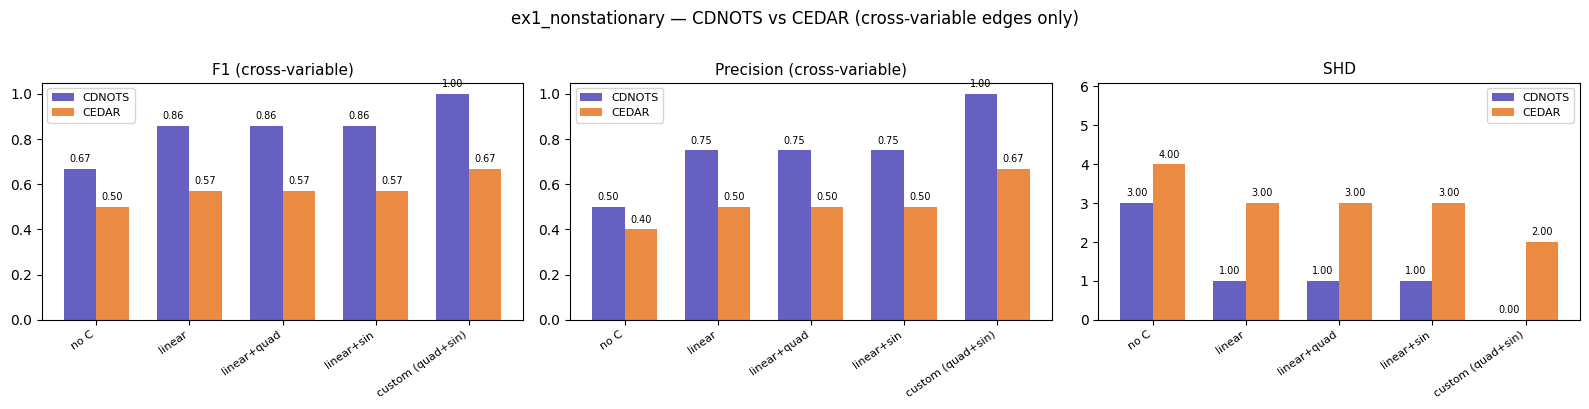

In [13]:
# Side-by-side: CDNOTS vs CEDAR on ex1_nonstationary (cross-variable)
cdnots_cross2 = {}
keys2 = list(cedar_results2.keys())   # ['no C', 'linear', 'linear+quad', 'linear+sin', 'custom (quad+sin)']
for key in keys2:
    m_cdnots, g_cdnots = results2.get(key, (None, None))
    if m_cdnots is None:
        cdnots_cross2[key] = None
    else:
        g_cdnots_x = g_cdnots[:d2, :d2, :] if g_cdnots.shape[0] > d2 else g_cdnots
        cdnots_cross2[key] = evaluate_graph(g_cdnots_x, gt2_cross, exclude_self_loops=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(keys2))
w = 0.35

for ax, metric, title, ymax in zip(
    axes,
    ['F1', 'Precision', 'SHD'],
    ['F1 (cross-variable)', 'Precision (cross-variable)', 'SHD'],
    [1.05, 1.05, None],
):
    cdnots_vals = [cdnots_cross2[k][metric] if cdnots_cross2.get(k) else 0 for k in keys2]
    cedar_vals   = [cedar_results2[k][0][metric] for k in keys2]
    if ymax is None:
        ymax = max(max(cdnots_vals), max(cedar_vals)) * 1.4 + 0.5

    b1 = ax.bar(x - w/2, cdnots_vals, w, label='CDNOTS', color='#4B44B8', alpha=0.85)
    b2 = ax.bar(x + w/2, cedar_vals,   w, label='CEDAR',  color='#E87722', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(keys2, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    for bar, v in zip(list(b1) + list(b2), cdnots_vals + cedar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax*0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('ex1_nonstationary — CDNOTS vs CEDAR (cross-variable edges only)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

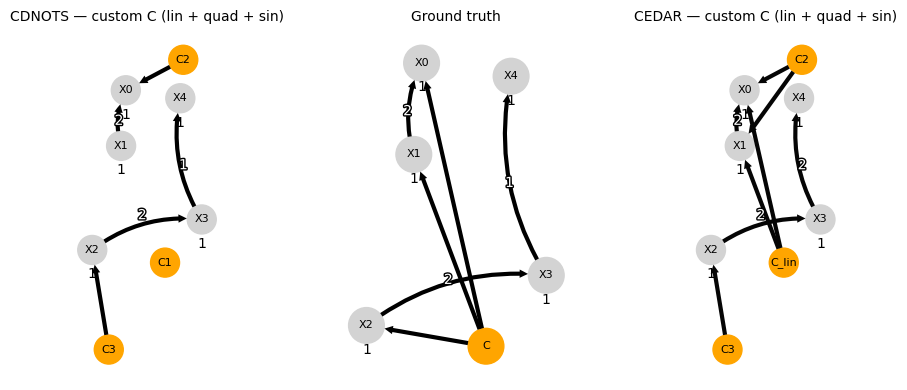

In [14]:
# Side-by-side: custom C result vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

pos2 = res2_cust.plot(
    arrow_linewidth=3,
    node_layout='fdp',
    fig_ax=(fig, axes[0]),
    node_label_size=8,
    node_size=0.2,
    show_autodependency_lags=True,
    special_nodes={('C1', 0): 'orange', ('C2', 0): 'orange', ('C3', 0): 'orange'},
    return_pos=True,
)

import causalts.plotting as tp
tp.plot_graph(
    gt2,
    var_names=var_names2,
    node_pos=pos2[2],
    node_label_size=8,
    node_size=0.15,
    arrow_linewidth=3,
    show_autodependency_lags=True,
    special_nodes={('C', 0): 'orange'},
    fig_ax=(fig, axes[1]),
)

res2_cust_s.plot(
    fig_ax=(fig, axes[2]),
    val_matrix=None,
    edge_color="#050505",
    node_pos=pos2[2],
    node_label_size=8,
    node_size=0.2,
    arrow_linewidth=3,
    show_autodependency_lags=True,
    special_nodes={('C_lin', 0): 'orange', ('C2', 0): 'orange', ('C3', 0): 'orange'},
)
axes[0].set_title('CDNOTS — custom C (lin + quad + sin)', fontsize=10)
axes[1].set_title('Ground truth', fontsize=10)
axes[2].set_title('CEDAR — custom C (lin + quad + sin)', fontsize=10)
plt.tight_layout()
plt.show()


## Summary
**Two roles for C:**

1. **Shared-trend confounder** (`confounded_trends`): variables driven by the
   same unobserved trend appear correlated without C; the right basis removes all
   spurious edges.
2. **Mechanism nonstationarity** (`ex1_nonstationary`): causal coefficients shift
   over time; C lets CI tests assess independence under the shifting mechanism.

**Power tradeoff**: each additional C column grows the conditioning set, reducing
CI test power for fixed T. Prefer the smallest basis that captures the pattern.